# Student Dropout Prediction Using Explainable Machine Learning

## Problem Statement

Student dropout is a significant challenge for educational institutions, as students may leave their studies due to a combination of academic, financial, demographic, and socioeconomic factors. Identifying students who are at risk of dropping out at an early stage can help institutions provide timely academic guidance, counselling, financial assistance, or other forms of support.

## Objectives

- Analyze the academic, demographic, and socioeconomic factors associated with student dropout.
- Perform exploratory data analysis to identify patterns and relationships within the data.
- Develop and compare multiple machine learning classification models for predicting student dropout.
- Evaluate the models using suitable classification metrics such as precision, recall, F1-score, and ROC-AUC.
- Use SHAP to interpret the model's predictions and identify the factors contributing to dropout risk.
- Develop a foundation for an interactive system that can identify students who may be at risk of dropping out.

## Dataset Description

The dataset contains information about students enrolled in higher education and includes demographic, socioeconomic, academic, and institutional attributes that may influence a student's academic outcome.

The dataset contains **35 columns**, including the target variable `Target`. The features include information such as:

- Demographic characteristics such as age, gender, nationality, and marital status
- Admission and previous qualification information
- Financial factors such as tuition fee status, scholarship status, and debtor status
- Academic performance during the first and second semesters
- Socioeconomic indicators such as unemployment rate, inflation rate, and GDP

### Target Variable

The `Target` variable represents the student's academic outcome and originally contains three classes:

- **Graduate** — the student successfully completed the course
- **Dropout** — the student left the course before completion
- **Enrolled** — the student was still enrolled when the data was collected

For the dropout prediction task, students labelled **Enrolled** are excluded because their final academic outcome is not yet known. The resulting problem is therefore treated as a **binary classification problem** between `Graduate` and `Dropout`.

In [5]:
import pandas as pd

df = pd.read_csv("../data/dataset.csv")

print(df.shape)

(4424, 35)


In [6]:
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [7]:
df.dtypes

Marital status                                      int64
Application mode                                    int64
Application order                                   int64
Course                                              int64
Daytime/evening attendance                          int64
Previous qualification                              int64
Nacionality                                         int64
Mother's qualification                              int64
Father's qualification                              int64
Mother's occupation                                 int64
Father's occupation                                 int64
Displaced                                           int64
Educational special needs                           int64
Debtor                                              int64
Tuition fees up to date                             int64
Gender                                              int64
Scholarship holder                                  int64
Age at enrollm

In [8]:
df.isnull().sum()

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrollment                                 0
International                                     0
Curricular u

In [9]:
df['Target'].value_counts()

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df = df[df['Target'] != 'Enrolled'].copy()

In [12]:
print(df['Target'].value_counts())

Target
Graduate    2209
Dropout     1421
Name: count, dtype: int64


In [13]:
print(df.shape)

(3630, 35)


In [14]:
df.groupby('Target')['Tuition fees up to date'].value_counts()

Target    Tuition fees up to date
Dropout   1                           964
          0                           457
Graduate  1                          2180
          0                            29
Name: count, dtype: int64

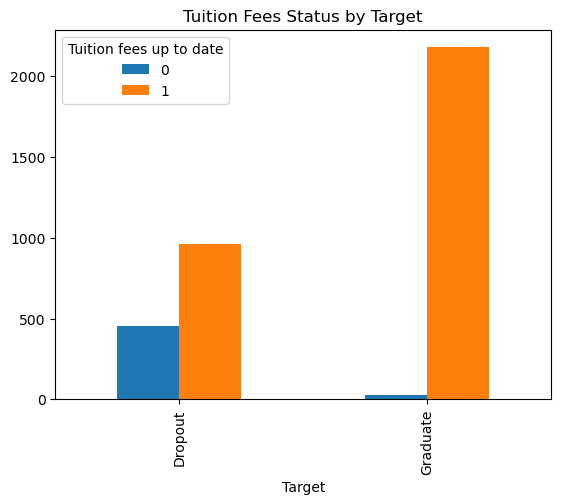

In [15]:
df.groupby('Target')['Tuition fees up to date'].value_counts().unstack().plot(kind='bar')
plt.title('Tuition Fees Status by Target')
plt.show()

blue- no, orange- yes

Among Dropouts, around 460 students had unpaid fees (blue) compared to only about 30 among Graduates. And among Graduates, almost all 2200 had fees up to date (orange). This shows that not paying tuition fees on time is a very strong indicator of dropout. Financial issues are a leading cause of students leaving university.

In [17]:
df.groupby('Target')['Scholarship holder'].value_counts()

Target    Scholarship holder
Dropout   0                     1287
          1                      134
Graduate  0                     1374
          1                      835
Name: count, dtype: int64

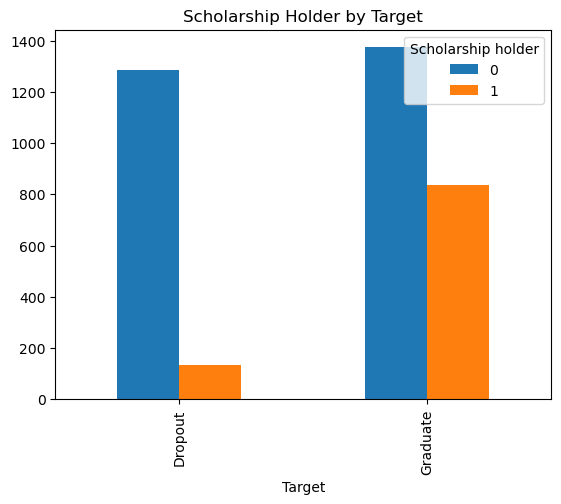

In [18]:
df.groupby('Target')['Scholarship holder'].value_counts().unstack().plot(kind='bar')
plt.title('Scholarship Holder by Target')
plt.show()

Among Dropouts, very few students (around 140) held a scholarship, while the majority (1290) did not. Among Graduates, the scholarship holders are much more (around 840). This suggests that having a scholarship significantly reduces the likelihood of dropping out, which makes sense since financial support removes one of the biggest barriers to completing a degree.

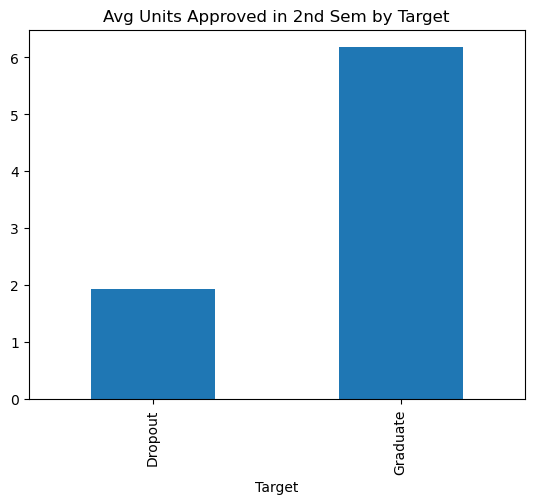

In [20]:
df.groupby('Target')['Curricular units 2nd sem (approved)'].mean().plot(kind='bar')
plt.title('Avg Units Approved in 2nd Sem by Target')
plt.show()

Graduates approved an average of 6.2 curricular units in their 2nd semester, while Dropouts approved only around 2. This strongly suggests that academic performance in the 2nd semester is one of the most powerful predictors of dropout. Students who are failing or not completing their units are much more likely to drop out.

In [22]:
df.groupby('Target')['Debtor'].value_counts()

Target    Debtor
Dropout   0         1109
          1          312
Graduate  0         2108
          1          101
Name: count, dtype: int64

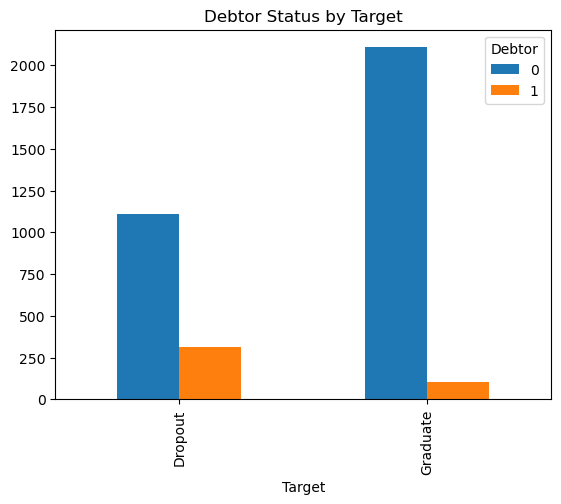

In [23]:
df.groupby('Target')['Debtor'].value_counts().unstack().plot(kind='bar')
plt.title('Debtor Status by Target')
plt.show()

Among Dropouts, around 300 students were debtors compared to only about 100 among Graduates. This further reinforces the financial theme, students with debt are at a higher risk of dropping out.

In [25]:
df['Target']=df['Target'].map({'Graduate':0,'Dropout':1})
print(df['Target'].value_counts())

Target
0    2209
1    1421
Name: count, dtype: int64


In [26]:
X=df.drop(columns=['Target'])
y=df['Target']

In [27]:
print(X.shape, y.shape)

(3630, 34) (3630,)


In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape, X_test.shape)

(2904, 34) (726, 34)


In [29]:
print(df.columns.tolist())

['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP', 'Target']


In [30]:
categorical_cols = [
    'Marital status',
    'Application mode',
    'Application order',
    'Course',
    'Daytime/evening attendance',
    'Previous qualification',
    'Nacionality',
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation"
]

In [31]:
numerical_cols = [
    'Age at enrollment',
    'Curricular units 1st sem (credited)',
    'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 1st sem (without evaluations)',
    'Curricular units 2nd sem (credited)',
    'Curricular units 2nd sem (enrolled)',
    'Curricular units 2nd sem (evaluations)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Curricular units 2nd sem (without evaluations)',
    'Unemployment rate',
    'Inflation rate',
    'GDP'
]

In [32]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numerical_cols)
    ],
    remainder='passthrough'
)

In [33]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Training data shape:", X_train_processed.shape)
print("Testing data shape:", X_test_processed.shape)

Training data shape: (2904, 231)
Testing data shape: (726, 231)


LOGISTIC REGRESSION

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [36]:
logreg = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)

In [37]:
print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("Precision:", round(precision_score(y_test, y_pred), 3))
print("Recall:", round(recall_score(y_test, y_pred), 3))
print("F1 Score:", round(f1_score(y_test, y_pred), 3))

Accuracy: 0.92
Precision: 0.869
Recall: 0.937
F1 Score: 0.902


In [38]:
y_prob = logreg.predict_proba(X_test)[:, 1]

print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 3))

ROC-AUC: 0.976


DECISION TREE

In [40]:
from sklearn.tree import DecisionTreeClassifier

In [41]:
dt = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(random_state=42, max_depth=5))
])

dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

In [42]:
print("Accuracy:", round(accuracy_score(y_test, y_pred_dt), 3))
print("Precision:", round(precision_score(y_test, y_pred_dt), 3))
print("Recall:", round(recall_score(y_test, y_pred_dt), 3))
print("F1 Score:", round(f1_score(y_test, y_pred_dt), 3))

Accuracy: 0.904
Precision: 0.918
Recall: 0.827
F1 Score: 0.87


In [43]:
y_prob_dt = dt.predict_proba(X_test)[:, 1]

print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_dt), 3))

ROC-AUC: 0.942


RANDOM FOREST

In [45]:
from sklearn.ensemble import RandomForestClassifier

In [46]:
rf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight='balanced'
    ))
])

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [47]:
print("Accuracy:", round(accuracy_score(y_test, y_pred_rf), 3))
print("Precision:", round(precision_score(y_test, y_pred_rf), 3))
print("Recall:", round(recall_score(y_test, y_pred_rf), 3))
print("F1 Score:", round(f1_score(y_test, y_pred_rf), 3))

Accuracy: 0.927
Precision: 0.939
Recall: 0.87
F1 Score: 0.903


In [48]:
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_rf), 3))

ROC-AUC: 0.973


XGBOOST

In [50]:
!pip install xgboost

In [51]:
from xgboost import XGBClassifier

In [52]:
xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators=100,
        random_state=42
    ))
])

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

In [53]:
print("Accuracy:", round(accuracy_score(y_test, y_pred_xgb), 3))
print("Precision:", round(precision_score(y_test, y_pred_xgb), 3))
print("Recall:", round(recall_score(y_test, y_pred_xgb), 3))
print("F1 Score:", round(f1_score(y_test, y_pred_xgb), 3))

Accuracy: 0.923
Precision: 0.907
Recall: 0.894
F1 Score: 0.901


In [54]:
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_xgb), 3))

ROC-AUC: 0.972


Model Comparison

In [56]:
results = {
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'XGBoost'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    'Precision': [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],
    'Recall': [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, y_prob_dt),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ]
}

results_df = pd.DataFrame(results)
results_df.round(3)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.920,0.869,0.937,0.902,0.976
1,Decision Tree,0.904,0.918,0.827,0.870,0.942
2,Random Forest,0.927,0.939,0.870,0.903,0.973
3,XGBoost,0.923,0.907,0.894,0.901,0.972


SHAP (Shapely Additive Explanation)

In [105]:
!pip install shap

   ---------------------------------------- 0.0/15.6 MB ? eta -:--:--
   ------ --------------------------------- 2.4/15.6 MB 11.2 MB/s eta 0:00:02
   ---------- ----------------------------- 4.2/15.6 MB 10.1 MB/s eta 0:00:02
   ------------------- -------------------- 7.6/15.6 MB 12.0 MB/s eta 0:00:01
   ---------------------------- ----------- 11.0/15.6 MB 13.0 MB/s eta 0:00:01
   ---------------------------------- ----- 13.4/15.6 MB 12.3 MB/s eta 0:00:01
   ---------------------------------------  15.5/15.6 MB 12.8 MB/s eta 0:00:01
   ---------------------------------------- 15.6/15.6 MB 11.8 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4


  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
orange3-imageanalytics 0.13.0 requires AnyQt, which is not installed.
orange3-imageanalytics 0.13.0 requires orange-canvas-core>=0.2.2, which is not installed.
orange3-imageanalytics 0.13.0 requires orange-widget-base>=4.23.0, which is not installed.
orange3-imageanalytics 0.13.0 requires Orange3>=3.35.0, which is not installed.
orange3-imageanalytics 0.13.0 requires requests-cache, which is not installed.
orange3-text 1.16.3 requires anyqt, which is not installed.
orange3-text 1.16.3 requires orange-canvas-core>=0.2.5, which is not installed.
orange3-text 1.16.3 requires orange-widget-base>=4.25.0, which is not installed.
orange3-text 1.16.3 requires Orange3>=3.38.1, which is not installed.
orange3-text 1.16.3 requires pyqtgraph, which is n

In [106]:
import shap

In [107]:
features = logreg.named_steps['preprocessor'].get_feature_names_out()
print(len(features))

231


In [108]:
model = logreg.named_steps['model']

In [113]:
exp = shap.LinearExplainer(model, X_train_processed)

Background dataset has 2904 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=2904 when initializing the masker.


In [115]:
shap_values = exp.shap_values(X_test_processed)

In [119]:
X_test_shap = pd.DataFrame(
    X_test_processed.toarray(),
    columns=features
)

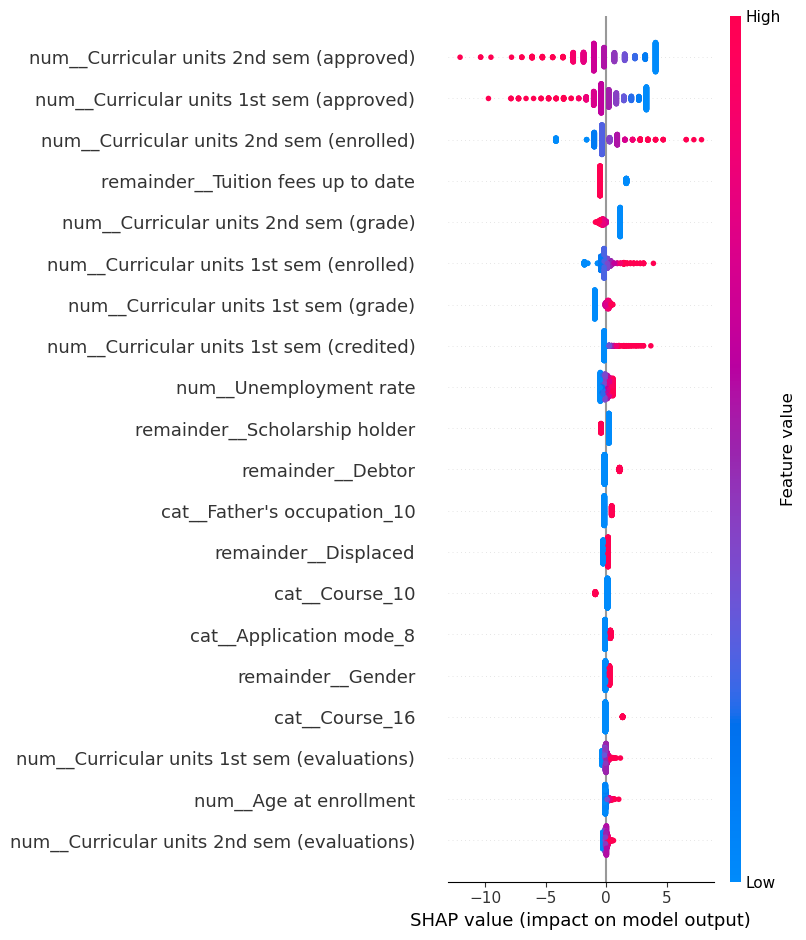

In [121]:
shap.summary_plot(
    shap_values,
    X_test_shap
)

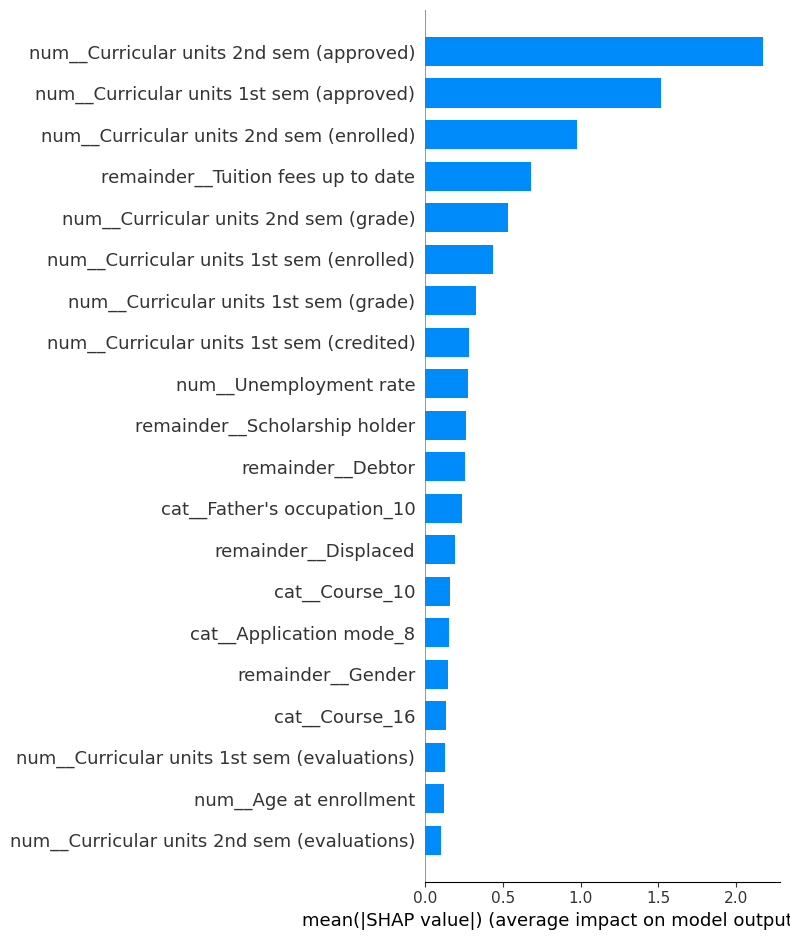

In [123]:
shap.summary_plot(
    shap_values,
    X_test_shap,
    plot_type="bar"
)

SHAP Analysis:
The model's predictions were primarily influenced by students' academic progress, particularly the number of curricular units approved and enrolled during the first and second semesters. Academic grades and tuition fee status were also important contributors. Lower academic progress and unfavorable financial status generally increased the predicted dropout risk, while stronger academic progress reduced it.